# Proof that the `_lambda.vis.npz` files used ONE wavelength for all spectral windows

The MS stores u, v in **metres** (`UVW`). Converting a row to wavelengths needs that row's own frequency:

$$u_\lambda = u_m \, \nu_{\rm row} / c$$

So for each row, `u_npz / u_m` should equal `ν_row / c`, which changes from one spectral window to the next. If it is the **same** number for every row, one wavelength was used for all of them.

Step 1 runs `ms_rowinfo.py` with the WSL CASA Python, because `casatools` is only available there. It saves each row's `u_m` and spectral window. Everything after that is plain numpy.

In [1]:
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

t = 'LkCa_15'
c = 2.99792458e8
casa_py = '/usr/local/bin/CASA/casa-6.6.1-17-pipeline-2024.1.0.8/lib/py/bin/python3'

# step 1 (CASA): u in metres + spectral window for every row the npz holds -> {t}_ms_rowinfo.npz
r = subprocess.run(['wsl', '-e', 'bash', '-lc', f'cd /mnt/d/CPD_MPIA/HPC_eqC1_gap && {casa_py} ms_rowinfo.py {t}'],
                   capture_output=True, text=True)
print(r.stdout.strip().splitlines()[-1])

ms = np.load(f'{t}_ms_rowinfo.npz')
u_m, spw_row, spwf = ms['u_m'], ms['spw_row'], ms['spwf']
npz = np.load(rf'D:\exoALMA_disk_data\measurement_set_spavg\npz\{t}_time_ave_continuum_spavg_lambda.vis.npz')
u_npz, wgt = npz['u'], npz['Wgt']
print('rows: MS (unflagged) =', len(u_m), '  npz =', len(u_npz))

saved LkCa_15_ms_rowinfo.npz 1950831 rows
rows: MS (unflagged) = 1950831   npz = 1950831


## 1. What the MS says: one frequency per spectral window

In [2]:
spw = pd.DataFrame([dict(spw=s, nu_GHz=spwf[s] / 1e9, lambda_mm=c / spwf[s] * 1e3, rows=np.sum(spw_row == s))
                    for s in np.unique(spw_row)])
print(len(spw), 'spectral windows, wavelengths', f"{spw.lambda_mm.min():.4f}-{spw.lambda_mm.max():.4f} mm")
spw

36 spectral windows, wavelengths 0.8669-0.9069 mm


,spw,nu_GHz,lambda_mm,rows
0,0,330.587099,0.906849,3789
1,1,331.569147,0.904163,3789
2,2,342.882058,0.874331,2972
3,3,345.795027,0.866966,3789
4,4,330.586882,0.906849,2478
5,5,331.568930,0.904163,2478
6,6,342.881833,0.874332,1291
7,7,345.794801,0.866966,2478
8,8,330.586486,0.906850,3564
9,9,331.568533,0.904164,3564


## 2. What the `_lambda` npz used: the implied wavelength of every row

implied wavelength: min 0.887745 mm, max 0.887746 mm, relative spread 1.4e-07
-> one wavelength for ALL 1944065 rows: 0.887746 mm = 337.7008 GHz
uvplot header (vis_txt) wavelength:          0.887746 mm


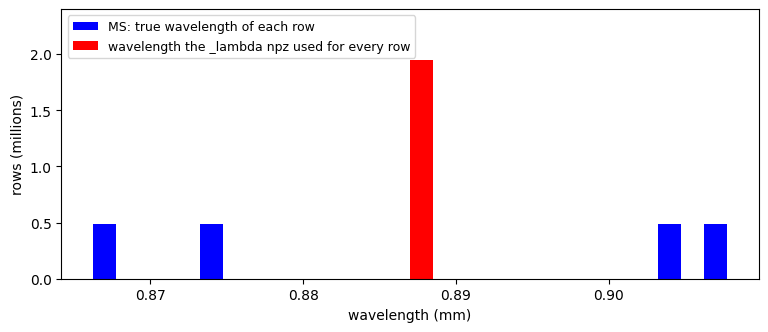

In [3]:
good = np.abs(u_m) > 1                # avoid dividing by ~0
lam_used = u_m[good] / u_npz[good]     # [m]
lam_hdr = float([l for l in open(rf'D:\exoALMA_disk_data\measurement_set_spavg\vis_txt\{t}_time_ave_continuum_spavg_vis.txt')
                 if 'wavelength[m]' in l][0].split('=')[1])
print(f"implied wavelength: min {lam_used.min() * 1e3:.6f} mm, max {lam_used.max() * 1e3:.6f} mm, "
      f"relative spread {lam_used.std() / lam_used.mean():.1e}")
print(f"-> one wavelength for ALL {good.sum()} rows: {np.median(lam_used) * 1e3:.6f} mm = {c / np.median(lam_used) / 1e9:.4f} GHz")
print(f"uvplot header (vis_txt) wavelength:          {lam_hdr * 1e3:.6f} mm")

# rows per wavelength: where the MS says each row is (blue) vs where the _lambda npz put it (red)
lam_true = np.round(c / spwf[spw_row] * 1e3, 3)   # mm, grouped to the 4 frequency settings
groups, counts = np.unique(lam_true, return_counts=True)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(groups, counts / 1e6, width=0.0015, color='b', label='MS: true wavelength of each row')
ax.bar(np.median(lam_used) * 1e3, good.sum() / 1e6, width=0.0015, color='r', label='wavelength the _lambda npz used for every row')
ax.set_xlabel('wavelength (mm)')
ax.set_ylabel('rows (millions)')
ax.set_ylim(0, 2.4)
ax.legend(fontsize=9, loc='upper left')
plt.show()

## 3. The resulting error per spectral window

The correct u is `npz u × ν_row / ν_used`. A source injected at radius r therefore lands at `r × ν_used / ν_row`.

In [4]:
nu_used = c / np.median(lam_used)
spw['u_scale_error_pct'] = 100 * (spw.nu_GHz * 1e9 / nu_used - 1)
spw['position_error_pct'] = 100 * (nu_used / (spw.nu_GHz * 1e9) - 1)
print(f"weight-averaged position error = {100 * (np.sum(wgt * nu_used / spwf[spw_row]) / np.sum(wgt) - 1):+.2f} %")
spw.round(4)

weight-averaged position error = +1.76 %


,spw,nu_GHz,lambda_mm,rows,u_scale_error_pct,position_error_pct
0,0,330.5871,0.9068,3789,-2.1065,2.1518
1,1,331.5691,0.9042,3789,-1.8157,1.8493
2,2,342.8821,0.8743,2972,1.5343,-1.5111
3,3,345.7950,0.8670,3789,2.3969,-2.3407
4,4,330.5869,0.9068,2478,-2.1066,2.1519
5,5,331.5689,0.9042,2478,-1.8158,1.8494
6,6,342.8818,0.8743,1291,1.5342,-1.5110
7,7,345.7948,0.8670,2478,2.3968,-2.3407
8,8,330.5865,0.9069,3564,-2.1067,2.1520
9,9,331.5685,0.9042,3564,-1.8159,1.8495
